# Analyzing temperature data 🌡️

### Use NOAA's NCEI Climate Data Online Search website to find a NYC Central Park sensor with measurements going back to the 1970s.
Use Daily Summary data and search for a station.<br>
https://www.ncei.noaa.gov/cdo-web/results

### We can download the data from the station detail site, but we can only get one month at a time. 

Data documentation is here: https://www.ncei.noaa.gov/products/land-based-station/global-historical-climatology-network-daily<br>
NOTE: data is available 45-60 days after the close of the month.

### Better way: CURL

Documentation here: https://github.com/curl/curl

Format:
curl http://data.rcc-acis.org/StnData\?sid\={STATION_ID}\&sdate\={START_DATE}\&edate\={END_DATE}\&elems\={ELEMENT}\&output\=json -o {DIRECTORY}/{FILE-NAME}.json

### Which variables do we need?

In [ ]:
# use full years of data in yyyy-mm-dd format

### Better way: CURL

curl http://data.rcc-acis.org/StnData\?sid\=USW00094728\&sdate\=1970-01-01\&edate\=2025-07-22\&elems\=maxt,mint\&output\=json



In [33]:
import json # let's us work with our json file
json_data = 'temperature_data/nyc-tmax-1970-2025.json'

In [34]:
with open(json_data, 'r') as f:
    data = json.load(f)

In [35]:
data

{'meta': {'uid': 18345,
  'll': [-73.96925, 40.77898],
  'sids': ['94728 1',
   '305801 2',
   'NYC 3',
   '72506 4',
   'KNYC 5',
   'USW00094728 6',
   'NYC 7',
   'USW00094728 32'],
  'state': 'NY',
  'elev': 140.0,
  'name': 'NY CITY CENTRAL PARK'},
 'data': [['1970-01-01', '25'],
  ['1970-01-02', '30'],
  ['1970-01-03', '36'],
  ['1970-01-04', '31'],
  ['1970-01-05', '34'],
  ['1970-01-06', '35'],
  ['1970-01-07', '25'],
  ['1970-01-08', '20'],
  ['1970-01-09', '14'],
  ['1970-01-10', '31'],
  ['1970-01-11', '30'],
  ['1970-01-12', '28'],
  ['1970-01-13', '33'],
  ['1970-01-14', '24'],
  ['1970-01-15', '28'],
  ['1970-01-16', '37'],
  ['1970-01-17', '47'],
  ['1970-01-18', '42'],
  ['1970-01-19', '23'],
  ['1970-01-20', '21'],
  ['1970-01-21', '19'],
  ['1970-01-22', '19'],
  ['1970-01-23', '27'],
  ['1970-01-24', '27'],
  ['1970-01-25', '36'],
  ['1970-01-26', '46'],
  ['1970-01-27', '34'],
  ['1970-01-28', '42'],
  ['1970-01-29', '51'],
  ['1970-01-30', '46'],
  ['1970-01-31', '

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

df = pd.DataFrame(data['data'])

In [37]:
df

,0,1
0,1970-01-01,25
1,1970-01-02,30
2,1970-01-03,36
3,1970-01-04,31
4,1970-01-05,34
...,...,...
20286,2025-07-17,90
20287,2025-07-18,82
20288,2025-07-19,81
20289,2025-07-20,88


In [38]:
df.columns = ['date', 'maxt']
df.head()

,date,maxt
0,1970-01-01,25
1,1970-01-02,30
2,1970-01-03,36
3,1970-01-04,31
4,1970-01-05,34


In [39]:
df.dtypes

date    object
maxt    object
dtype: object

In [40]:
df['date'] = pd.to_datetime(df['date'])
df['maxt'] = pd.to_numeric(df['maxt'])

In [28]:
df.dtypes

date    datetime64[ns]
maxt            object
dtype: object

In [42]:
df.describe()

,date,maxt
count,20291,20291.000000
mean,1997-10-11 00:00:00,62.893549
min,1970-01-01 00:00:00,9.000000
25%,1983-11-21 12:00:00,48.000000
50%,1997-10-11 00:00:00,64.000000
75%,2011-08-31 12:00:00,79.000000
max,2025-07-21 00:00:00,104.000000
std,NaN,18.256180


<Axes: xlabel='date', ylabel='maxt'>

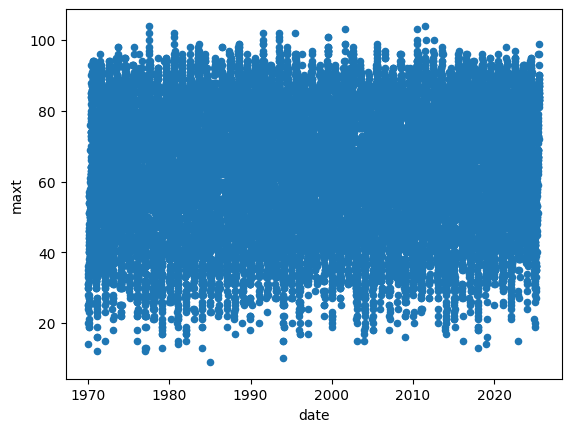

In [45]:
df.plot(x='date', y='maxt', kind='scatter')

In [47]:
# add new column for year

df['year'] = df['date'].dt.year
df.head()

,date,maxt,year
0,1970-01-01,25,1970
1,1970-01-02,30,1970
2,1970-01-03,36,1970
3,1970-01-04,31,1970
4,1970-01-05,34,1970


In [48]:
full_years = df[df['year'] <= 2024]
df.head(-3)

,date,maxt,year
0,1970-01-01,25,1970
1,1970-01-02,30,1970
2,1970-01-03,36,1970
3,1970-01-04,31,1970
4,1970-01-05,34,1970
...,...,...,...
20283,2025-07-14,85,2025
20284,2025-07-15,86,2025
20285,2025-07-16,87,2025
20286,2025-07-17,90,2025


In [50]:
# calculate average change per year

np.polyfit(full_years['year'], full_years['maxt'], 1)

array([0.02784646, 7.30518455])

In [51]:
slope, intercept = np.polyfit(full_years['year'], full_years['maxt'], 1)

In [52]:
slope

np.float64(0.02784645776621585)

In [53]:
slope*(full_years['year'].max()-full_years['year'].min())

np.float64(1.5037087193756558)